# 가설 1 — 지역마다 다른 배송 기대치와 고객 만족도

검증할 가설: **만족스러운 배송 시간의 기준은 지역마다 다르고, 같은 소요 일수라도
지역에 따라 고객 만족도가 다르게 나타난다.**

가설이 서 있는 논리는 셋.

1. 지역마다 배송에 걸리는 시간이 다름
2. 고객도 자기 지역의 배송 속도를 어느 정도 알고 있음
3. 그렇다면 만족의 기준선이 지역마다 다르므로, 같은 소요 일수에서도 만족도 분포가 달라짐

배송이 느리면 만족도가 낮다는 것은 확인할 필요가 적음. 확인해야 하는 것은 **기준선이 지역마다
다른가**. 20 일이 걸린 주문은 중앙값이 26 일인 주에서는 빠른 편이고 7 일인 주에서는 세 배 늦은 것.

고객이 가진 기대치의 후보는 둘. **그 지역의 통상 소요 시간**과,
주문 시점에 플랫폼이 제시한 **예상 도착일**. 후자는 플랫폼이 지역차를 이미 반영해 산출했을
가능성이 있어 둘을 함께 확인.

고객 만족도는 05 에서 정한 대로 리뷰 점수(1 ~ 5)로 측정. 공용 표본과 축약 규칙도 05 를 따르며
뷰 `order_review` 를 그대로 사용.

**확인 항목**

- 표본 — 배송을 겪은 주문으로 좁히기
- 배송 소요 시간 — 정의와 분포
- 지역별 배송 소요 시간 — 논리 1
- 소요 시간과 고객 만족도의 관계 — 기준선이 하나뿐이라면 이것으로 끝
- 같은 소요 일수에서의 지역별 만족도 차이 — 논리 3
- 기대치의 두 후보 비교 — 지역의 통상 소요 시간 대비, 예상 도착일 대비

## 0. 연결

05 가 만든 뷰 `order_review` 를 사용하므로 05 실행 이후의 상태가 전제.
처음부터 다시 돌릴 때는 02 로 원본을 복원한 뒤 03 · 04 · 05 · 06 순서로 실행.

In [1]:
import duckdb

con = duckdb.connect('../olist.duckdb')

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'Malgun Gothic'
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi'] = 110
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.25
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

FAST, MID, SLOW = '#3C6E9F', '#D9A05B', '#B3524B'

## 1. 표본 좁히기

05 의 공용 표본은 리뷰가 달린 주문 전부. 이 가설은 배송에 걸린 시간을 다루므로
**배송이 완료되었고 완료 시각이 기록된 주문**으로 좁힘.

- `order_status = 'delivered'` — 취소·미출고·배송 중인 주문 제외
- 배송 완료일 있음 — 상태는 `delivered` 이나 완료 시각이 비어 있어 소요 시간을 잴 수 없는 주문 제외

두 조건에서 빠지는 규모를 확인.

In [3]:
con.execute("""
SELECT '1. 공용 표본' AS step,
       COUNT(*)      AS rows
FROM order_review

UNION ALL
SELECT '2. + 배송 완료', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'

UNION ALL
SELECT '3. + 배송 완료일 있음', COUNT(*)
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL

ORDER BY step
""").df()

,step,rows
0,1. 공용 표본,98330
1,2. + 배송 완료,95568
2,3. + 배송 완료일 있음,95560


공용 표본 98,330 건에서 2,762 건이 배송 미완료로 제외되고,
`delivered` 이나 완료 시각이 없는 8 건이 더 빠져 95,560 건.
공용 표본의 97.2 % 가 잔존.

배송 미완료 2,762 건은 취소·미출고·배송 중인 주문. 배송을 겪지 않았으므로 이 가설의 대상이 아님.
완료 시각이 없는 8 건은 배송 자체는 이루어졌으나 시각이 기록되지 않아 소요 시간을 잴 수 없는 주문.

## 2. 배송 소요 시간의 분포

배송 소요 시간과 약속 대비는 05 에서 정의한 값을 그대로 사용.
1 에서 좁힌 표본을 뷰 `delivery_review` 로 고정하고 이후 절은 모두 이 뷰를 사용.

승인·출고 같은 중간 시각으로는 구간을 쪼개지 않음. 고객이 겪는 기다림의 시작점은 주문한 순간이고,
중간 시각에는 순서가 뒤집힌 행이 있어 구간을 나누면 음수가 발생.

분포를 보고 이후 절에서 평균과 중앙값 중 무엇으로 비교할지 결정.

In [4]:
con.execute("""
CREATE OR REPLACE VIEW delivery_review AS
SELECT *
FROM order_review
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NOT NULL
""")

con.execute("""
SELECT COUNT(*)             AS orders,
       COUNT(delivery_days) AS with_days
FROM delivery_review
""").df()

,orders,with_days
0,95560,95560


In [5]:
con.execute("""
SELECT COUNT(*)                             AS orders,
       MIN(delivery_days)                   AS min_days,
       ROUND(AVG(delivery_days), 1)         AS avg_days,
       MEDIAN(delivery_days)                AS median_days,
       QUANTILE_CONT(delivery_days, 0.90)   AS p90_days,
       QUANTILE_CONT(delivery_days, 0.99)   AS p99_days,
       MAX(delivery_days)                   AS max_days,
       COUNT(*) FILTER (delivery_days > 30) AS over_30d,
       COUNT(*) FILTER (delivery_days > 60) AS over_60d
FROM delivery_review
""").df()

,orders,min_days,avg_days,median_days,p90_days,p99_days,max_days,over_30d,over_60d
0,95560,0,12.4,10.0,23.0,46.0,208,4135,281


95,560 건 전부 소요일이 계산됨.

중앙값 10 일, 평균 12.4 일. 평균이 중앙값보다 2.4 일 큼.
최솟값 0 일, p90 23 일, p99 46 일, 최댓값 208 일로 오른쪽 꼬리가 김.
30 일을 넘긴 주문이 4,135 건(4.3 %), 60 일을 넘긴 주문이 281 건(0.29 %).

꼬리가 평균을 끌어올리므로 지역별 비교는 **중앙값**으로 수행.
평균만 보면 표본이 작은 주에서 극단값 몇 건이 순위를 뒤집을 수 있음.
건수를 함께 실어 규모가 작은 주를 구분.

## 3. 주별 배송 소요 시간

가설의 첫 마디 — 지역에 따라 배송 소요 시간이 다른가.

먼저 주(`customer_state`) 단위로 비교. 도시로 내릴지는 4 에서 판단.

중앙값을 기준으로 두고 평균을 나란히 확인. 두 값이 크게 벌어지는 주는 소수의 오래 걸린 주문이
평균을 끌어올린 경우.

주문 수가 적은 주는 중앙값도 흔들리므로 건수를 함께 표시.

In [6]:
con.execute("""
SELECT customer_state,
       COUNT(*)                                           AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct,
       MEDIAN(delivery_days)                              AS median_days,
       ROUND(AVG(delivery_days), 1)                       AS avg_days,
       QUANTILE_CONT(delivery_days, 0.90)                 AS p90_days
FROM delivery_review
GROUP BY customer_state
ORDER BY median_days DESC
""").df()

,customer_state,orders,pct,median_days,avg_days,p90_days
0,AM,144,0.15,26.0,26.3,39.0
1,RR,40,0.04,25.0,29.9,53.1
2,AP,66,0.07,24.5,27.1,34.5
3,AL,393,0.41,22.0,24.4,39.0
4,PA,929,0.97,21.0,23.6,39.0
5,MA,709,0.74,19.0,21.4,34.0
6,AC,80,0.08,18.0,21.0,31.2
7,CE,1267,1.33,18.0,21.1,34.0
8,RO,242,0.25,18.0,19.3,29.0
9,PB,511,0.53,18.0,20.2,34.0


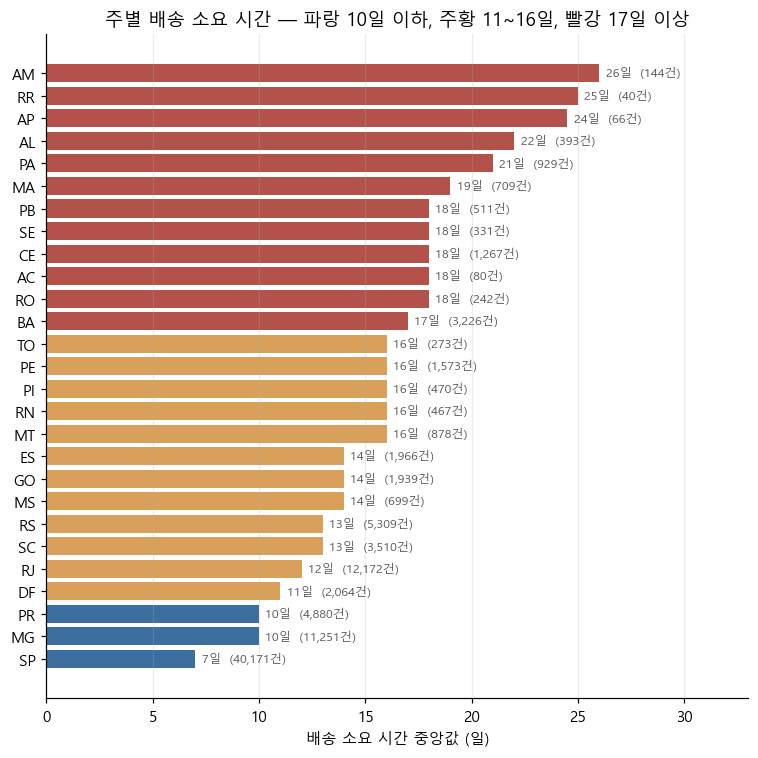

In [7]:
df = con.execute("""
SELECT customer_state,
       COUNT(*)              AS orders,
       MEDIAN(delivery_days) AS median_days
FROM delivery_review
GROUP BY customer_state
ORDER BY median_days
""").df()

colors = [FAST if m <= 10 else MID if m <= 16 else SLOW for m in df.median_days]

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(df.customer_state, df.median_days, color=colors)
for y, (m, n) in enumerate(zip(df.median_days, df.orders)):
    ax.text(m + 0.3, y, f'{m:.0f}일  ({n:,}건)', va='center', fontsize=8, color='#555')
ax.set_xlim(0, 33)
ax.set_xlabel('배송 소요 시간 중앙값 (일)')
ax.set_title('주별 배송 소요 시간 — 파랑 10일 이하, 주황 11~16일, 빨강 17일 이상')
ax.grid(axis='y', visible=False)
plt.tight_layout()
plt.show()

주별 중앙값이 SP 7 일에서 AM 26 일까지 3.7 배 차이.
지역에 따라 배송 소요 시간이 다르다는 첫 마디는 성립.

오래 걸리는 상위권은 북부·북동부에 몰려 있음 — AM 26 일, RR 25 일, AP 24.5 일, AL 22 일, PA 21 일.
짧은 쪽은 남동부 — SP 7 일, MG·PR 10 일, DF 11 일, RJ 12 일.

상위권 주는 주문이 적어(RR 40 건, AP 66 건, AC 80 건, AM 144 건) 중앙값이 흔들릴 수 있음.
다만 규모가 있는 북동부 주도 같은 방향 — BA 3,226 건 17 일, CE 1,267 건 18 일, PE 1,573 건 16 일.
표본이 작아서 생긴 경향이 아님.

**주문의 지역 쏠림이 큼.** SP 42.04 %, RJ 12.74 %, MG 11.77 % 로 세 주가 66.6 %.
나머지 24 개 주가 33.4 % 를 나눠 가짐. 전체 평균은 사실상 SP 의 값에 가깝게 끌려가므로,
지역 차이를 볼 때는 전체 평균과 비교하지 않고 주별로 나란히 놓아야 함.

평균은 모든 주에서 중앙값보다 큼. 격차가 큰 곳은 RR(25 → 29.9), AP(24.5 → 27.1),
그리고 규모가 큰 주 중에서는 RJ(12 → 15.2). RJ 는 p90 이 29 일로 중앙값이 비슷한
RS(26 일)·SC(25.1 일)보다 길어 오래 걸린 주문의 꼬리가 두꺼움.

SP 가 7 일로 유독 짧은 이유는 이 표에서 드러나지 않음. 판매자의 소재지가 SP 에 몰려 있는지는
`sellers` 로 확인할 수 있으며, 별도 가설로 다룰 대상.

## 4. 지역의 단위 — 주인가 도시인가

3 에서 주 단위로 보았으나 SP 한 주가 표본의 42 % 를 차지한다.
주 안에서도 대도시와 내륙은 배송 환경이 다를 수 있어, 주 단위로 묶으면 그 편차가 사라짐.

도시로 내리려면 쪼갠 뒤에도 비교할 만한 규모가 남아야 함. 세 가지를 확인.

- 도시 단위의 규모 분포 — 기준별로 몇 개 도시가 남고 그것이 표본의 몇 % 인지
- 상위 도시의 집중도 — 소수의 도시가 표본을 덮는지
- SP 주 내부의 도시별 편차 — 주 하나로 묶어도 되는지

도시는 `(customer_city, customer_state)` 로 묶음. 같은 도시명이 서로 다른 주에 존재.

In [8]:
con.execute("""
WITH city AS (
    SELECT customer_state,
           customer_city,
           COUNT(*)              AS orders,
           MEDIAN(delivery_days) AS median_days
    FROM delivery_review
    GROUP BY customer_state, customer_city
)
SELECT COUNT(*)                                                            AS cities,
       COUNT(*) FILTER (orders >= 100)                                     AS cities_100,
       COUNT(*) FILTER (orders >= 300)                                     AS cities_300,
       COUNT(*) FILTER (orders >= 1000)                                    AS cities_1000,
       ROUND(100.0 * SUM(orders) FILTER (orders >= 100)  / SUM(orders), 2) AS pct_100,
       ROUND(100.0 * SUM(orders) FILTER (orders >= 300)  / SUM(orders), 2) AS pct_300,
       ROUND(100.0 * SUM(orders) FILTER (orders >= 1000) / SUM(orders), 2) AS pct_1000
FROM city
""").df()

,cities,cities_100,cities_300,cities_1000,pct_100,pct_300,pct_1000
0,4267,134,38,9,66.44,49.27,34.16


도시 4,267 개 중 주문 100 건 이상은 134 개이며 이들이 표본의 66.4 %.
300 건 이상은 38 개로 49.3 %, 1,000 건 이상은 9 개로 34.2 %.
도시로 내리면 나머지 33.6 % 가 4,133 개 도시로 흩어져 비교 대상이 되지 못함.

In [9]:
con.execute("""
WITH city AS (
    SELECT customer_state,
           customer_city,
           COUNT(*)              AS orders,
           MEDIAN(delivery_days) AS median_days
    FROM delivery_review
    GROUP BY customer_state, customer_city
)
SELECT customer_state,
       customer_city,
       orders,
       ROUND(100.0 * orders / SUM(orders) OVER (), 2) AS pct,
       ROUND(100.0 * SUM(orders) OVER (ORDER BY orders DESC
                                       ROWS UNBOUNDED PRECEDING)
                   / SUM(orders) OVER (), 2)          AS cum_pct,
       median_days
FROM city
ORDER BY orders DESC
LIMIT 15
""").df()

,customer_state,customer_city,orders,pct,cum_pct,median_days
0,SP,sao paulo,14916,15.61,15.61,6.0
1,RJ,rio de janeiro,6504,6.81,22.42,12.0
2,MG,belo horizonte,2672,2.80,25.21,9.0
3,DF,brasilia,2055,2.15,27.36,11.0
4,PR,curitiba,1475,1.54,28.91,9.0
5,SP,campinas,1388,1.45,30.36,8.0
6,RS,porto alegre,1333,1.39,31.75,13.0
7,BA,salvador,1172,1.23,32.98,17.0
8,SP,guarulhos,1133,1.19,34.16,7.0
9,SP,sao bernardo do campo,906,0.95,35.11,6.0


규모가 고르지 않음. 상파울루시 15.6 %, 리우데자네이루 6.8 % 인데 3 위 벨루오리존치가 2.8 %.
비교할 만한 크기의 도시는 둘뿐이고 나머지는 급격히 작아짐.
누적 비율을 보면 상위 15 개 도시를 합쳐도 39 %.

In [10]:
con.execute("""
SELECT customer_city,
       COUNT(*)                     AS orders,
       MEDIAN(delivery_days)        AS median_days,
       ROUND(AVG(review_score), 2)  AS avg_score
FROM delivery_review
WHERE customer_state = 'SP'
GROUP BY customer_city
HAVING COUNT(*) >= 300
ORDER BY median_days
""").df()

,customer_city,orders,median_days,avg_score
0,barueri,418,6.0,4.22
1,osasco,719,6.0,4.25
2,santo andre,771,6.0,4.32
3,carapicuiba,314,6.0,4.20
4,sao bernardo do campo,906,6.0,4.32
5,piracicaba,355,6.0,4.26
6,sao paulo,14916,6.0,4.23
7,mogi das cruzes,370,6.0,4.21
8,sorocaba,604,7.0,4.35
9,maua,314,7.0,4.20


SP 주에서 주문 300 건 이상인 도시 17 개. 중앙값이 6 ~ 8 일에 몰려 있고
만족도도 4.15 ~ 4.35 로 좁은 범위. 상파울루 대도시권은 서로 비슷하다.
다만 이 17 개 도시가 SP 주문의 62 % 이므로 나머지 소도시가 다를 가능성이 남는다.

In [11]:
con.execute("""
WITH city AS (
    SELECT customer_state,
           customer_city,
           COUNT(*) AS city_orders
    FROM delivery_review
    GROUP BY customer_state, customer_city
)
SELECT CASE WHEN c.city_orders >= 300 THEN '1. 300건 이상'
            WHEN c.city_orders >= 100 THEN '2. 100~299건'
            WHEN c.city_orders >=  30 THEN '3. 30~99건'
            ELSE                           '4. 30건 미만' END AS city_size,
       COUNT(DISTINCT d.customer_city)                        AS cities,
       COUNT(*)                                               AS orders,
       MEDIAN(d.delivery_days)                                AS median_days,
       QUANTILE_CONT(d.delivery_days, 0.90)                   AS p90_days,
       ROUND(AVG(d.review_score), 2)                          AS avg_score
FROM delivery_review AS d
JOIN city            AS c ON d.customer_state = c.customer_state
                         AND d.customer_city  = c.customer_city
WHERE d.customer_state = 'SP'
GROUP BY city_size
ORDER BY city_size
""").df()

,city_size,cities,orders,median_days,p90_days,avg_score
0,1. 300건 이상,17,24927,7.0,15.0,4.24
1,2. 100~299건,37,6749,7.0,16.0,4.22
2,3. 30~99건,85,5046,8.0,17.0,4.27
3,4. 30건 미만,488,3449,9.0,17.0,4.32


SP 주 안에서 도시를 규모별로 묶어도 차이가 작다.
300 건 이상 17 개 도시 중앙값 7 일, 100 ~ 299 건 37 개 도시 7 일, 30 ~ 99 건 85 개 도시 8 일,
30 건 미만 488 개 도시 9 일.

**주 안에서의 폭이 7 ~ 9 일인 반면 주 사이의 폭은 7 ~ 26 일.**

네 표를 종합하면 도시로 내릴 때 얻는 것보다 잃는 것이 큼.
도시 단위는 표본의 3 분의 1 을 비교에서 잃고, 얻는 편차는 주 단위로 묶었을 때 사라지는 2 일 남짓.

이후 절은 주 단위로 진행. 다만 SP 가 표본의 42 % 라 전체 집계가 SP 값에 가깝게 끌려간다는 점은
계속 유의.

한 가지 눈에 띄는 것. SP 안에서 도시가 작을수록 배송은 느린데 만족도는 오히려 높음 —
300 건 이상 도시가 7 일에 4.24, 30 건 미만 도시가 9 일에 4.32.

## 5. 소요 시간과 고객 만족도의 관계

가설의 논리 2 는 고객이 자기 지역의 배송 속도를 안다는 것이고, 논리 3 은 그래서 만족의 기준선이
지역마다 다르다는 것. 지역을 나누기 전에 **전체에서 소요 시간과 만족도가 어떻게 움직이는지** 확인.

기준선이 지역과 무관하게 하나뿐이라면 소요 일수만으로 만족도가 설명되고, 지역을 나눠도
같은 소요 일수에서는 같은 만족도가 나와야 함.

소요일을 구간으로 나눠 평균 만족도와 1 점·5 점의 비율을 확인.
평균만 보면 1 점과 5 점이 섞여 중간값이 되는 경우를 구분하지 못함.

In [12]:
con.execute("""
SELECT CASE WHEN delivery_days <=  3 THEN '1. 0~3일'
            WHEN delivery_days <=  7 THEN '2. 4~7일'
            WHEN delivery_days <= 14 THEN '3. 8~14일'
            WHEN delivery_days <= 21 THEN '4. 15~21일'
            WHEN delivery_days <= 30 THEN '5. 22~30일'
            ELSE                          '6. 31일 이상' END      AS days_bucket,
       COUNT(*)                                                   AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)         AS pct,
       ROUND(AVG(review_score), 2)                                AS avg_score,
       ROUND(100.0 * COUNT(*) FILTER (review_score = 1) / COUNT(*), 1) AS pct_1,
       ROUND(100.0 * COUNT(*) FILTER (review_score = 5) / COUNT(*), 1) AS pct_5
FROM delivery_review
GROUP BY days_bucket
ORDER BY days_bucket
""").df()

,days_bucket,orders,pct,avg_score,pct_1,pct_5
0,1. 0~3일,6926,7.25,4.46,5.0,71.0
1,2. 4~7일,23590,24.69,4.40,5.5,67.3
2,3. 8~14일,37695,39.45,4.30,6.6,62.5
3,4. 15~21일,15995,16.74,4.12,8.8,54.8
4,5. 22~30일,7219,7.55,3.54,20.0,39.3
5,6. 31일 이상,4135,4.33,2.19,56.2,15.5


구간으로 묶으면 소요일이 길수록 만족도가 낮아지는 방향은 보이나
어디서 얼마나 꺾이는지는 알 수 없음. 구간 경계가 임의로 정한 것이기 때문.
하루 단위로 펼쳐 확인.

In [13]:
con.execute("""
SELECT CASE WHEN delivery_days >= 46 THEN 46 ELSE delivery_days END      AS days,
       COUNT(*)                                                         AS orders,
       ROUND(AVG(review_score), 3)                                      AS avg_score,
       ROUND(100.0 * COUNT(*) FILTER (review_score = 1) / COUNT(*), 1)  AS pct_1
FROM delivery_review
GROUP BY days
ORDER BY days
""").df()

,days,orders,avg_score,pct_1
0,0,1,5.000,0.0
1,1,628,4.525,4.5
2,2,2863,4.487,4.5
3,3,3434,4.430,5.6
4,4,4478,4.447,4.8
5,5,5231,4.404,5.4
6,6,6474,4.378,5.8
7,7,7407,4.380,5.8
8,8,7067,4.360,5.6
9,9,6210,4.332,6.3


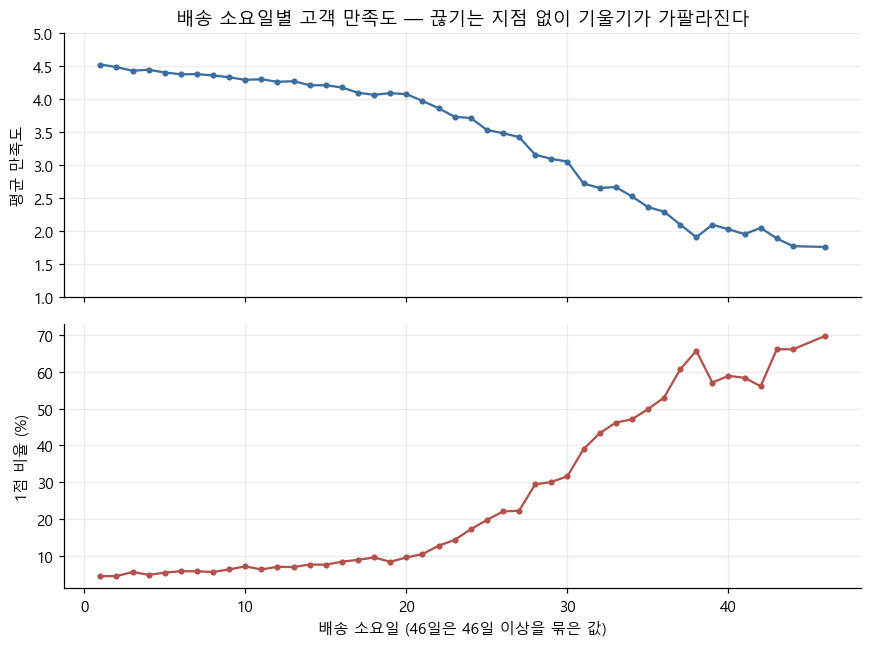

In [14]:
df = con.execute("""
SELECT CASE WHEN delivery_days >= 46 THEN 46 ELSE delivery_days END  AS days,
       COUNT(*)                                                     AS orders,
       AVG(review_score)                                            AS avg_score,
       100.0 * COUNT(*) FILTER (review_score = 1) / COUNT(*)         AS pct_1
FROM delivery_review
GROUP BY days
HAVING COUNT(*) >= 100
ORDER BY days
""").df()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

ax1.plot(df.days, df.avg_score, marker='o', ms=3, color='#3C6E9F')
ax1.set_ylabel('평균 만족도')
ax1.set_ylim(1, 5)
ax1.set_title('배송 소요일별 고객 만족도 — 끊기는 지점 없이 기울기가 가팔라진다')

ax2.plot(df.days, df.pct_1, marker='o', ms=3, color='#B3524B')
ax2.set_ylabel('1점 비율 (%)')
ax2.set_xlabel('배송 소요일 (46일은 46일 이상을 묶은 값)')

plt.tight_layout()
plt.show()

하루 단위로 보면 소요일 30 일까지 하루마다 400 건 이상이 있어 곡선이 매끄럽게 그려짐.
46 일 이상은 984 건을 하나로 묶음.

소요 시간과 만족도는 뚜렷하게 반대 방향이다.

구간으로 묶으면 어디서 얼마나 꺾이는지 알 수 없어 하루 단위로 펼쳐 확인.
소요일 30 일까지는 하루마다 400 건 이상이 있어 곡선이 매끄럽게 그려짐.

**특정 지점에서 무너지는 것이 아니라 기울기가 점점 가팔라지는 곡선.**
1 일 4.525 에서 14 일 4.211 까지는 하루당 약 0.023 씩 하락하고,
20 일 4.077 을 지나면서 하루당 약 0.10 으로 네 배 이상 가팔라짐.
30 일 3.057, 35 일 2.368, 40 일 2.032.

가팔라지기 시작하는 지점은 16 ~ 17 일 부근이나 특정 날짜에 값이 끊기지는 않음.
구간을 나눠 놓고 그 경계에 임계점이 있다고 말할 수 없는 형태.

1 점 비율도 같은 모양. 1 ~ 10 일에서 4.5 ~ 7.1 % 이던 것이 20 일 9.5 %, 30 일 31.6 %,
40 일 58.9 % 로 커짐.

다만 이 곡선은 두 가지를 섞고 있음. 오래 기다린 것 자체의 효과와, 오래 걸린 주문일수록
약속을 어겼을 가능성이 높다는 것. 둘을 가르는 작업은 7 에서 수행.

가설이 묻는 것은 이 곡선이 지역마다 다른 위치에 놓이는가. 다음 절에서 지역을 나눠 확인.

## 6. 같은 소요 일수에서의 지역별 만족도

가설의 핵심. 5 에서 본 임계점이 지역과 무관하게 하나뿐인지, 지역마다 다른지 확인.

주를 배송 속도로 세 무리로 묶음. 27 개 주를 소요일 구간과 교차하면 칸이 잘게 쪼개져
읽기 어렵고 표본이 작은 칸이 생김. 주별 중앙값을 기준으로 삼는다.

- 빠른 주 — 중앙값 10 일 이하
- 중간 주 — 11 ~ 16 일
- 느린 주 — 17 일 이상

같은 소요일 구간 안에서 세 무리의 만족도를 비교.
기준선이 하나뿐이라면 세 값이 비슷해야 하고, 지역마다 다르다면 느린 주에서 더 높아야 함.

무리가 어떻게 나뉘었는지 먼저 확인. 기준은 주별 중앙값.

In [15]:
con.execute("""
WITH s AS (
    SELECT customer_state,
           COUNT(*)              AS orders,
           MEDIAN(delivery_days) AS median_days
    FROM delivery_review
    GROUP BY customer_state
)
SELECT CASE WHEN median_days <= 10 THEN '1. 빠른 주'
            WHEN median_days <= 16 THEN '2. 중간 주'
            ELSE                        '3. 느린 주' END AS speed_group,
       COUNT(*)                                        AS states,
       SUM(orders)                                     AS orders,
       ROUND(100.0 * SUM(orders) / SUM(SUM(orders)) OVER (), 1) AS pct,
       MIN(median_days)                                AS min_median,
       MAX(median_days)                                AS max_median,
       STRING_AGG(customer_state, ' ' ORDER BY median_days) AS states_list
FROM s
GROUP BY speed_group
ORDER BY speed_group
""").df()

,speed_group,states,orders,pct,min_median,max_median,states_list
0,1. 빠른 주,3,56302.0,58.9,7.0,10.0,SP PR MG
1,2. 중간 주,12,31320.0,32.8,11.0,16.0,DF RJ RS SC ES GO MS RN TO PI MT PE
2,3. 느린 주,12,7938.0,8.3,17.0,26.0,BA CE AC RO PB SE MA PA AL AP RR AM


In [16]:
from IPython.display import display

sql = """
WITH state_speed AS (
    SELECT customer_state,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '1. 빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '2. 중간 주'
                ELSE                                  '3. 느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
)
SELECT CASE WHEN delivery_days <=  3 THEN '1. 0~3일'
            WHEN delivery_days <=  7 THEN '2. 4~7일'
            WHEN delivery_days <= 14 THEN '3. 8~14일'
            WHEN delivery_days <= 21 THEN '4. 15~21일'
            WHEN delivery_days <= 30 THEN '5. 22~30일'
            ELSE                          '6. 31일 이상' END               AS days_bucket,
       COUNT(*)                                                           AS orders,
       ROUND(AVG(review_score), 2)                                        AS avg_score,
       ROUND(STDDEV_SAMP(review_score) / SQRT(COUNT(*)), 3)               AS se,
       ROUND(100.0 * COUNT(*) FILTER (review_score = 1) / COUNT(*), 1)    AS pct_1
FROM delivery_review AS d
JOIN state_speed     AS s ON d.customer_state = s.customer_state
WHERE s.speed_group = '{group}'
GROUP BY days_bucket
ORDER BY days_bucket
"""

for group in ['1. 빠른 주', '2. 중간 주', '3. 느린 주']:
    print(group)
    display(con.execute(sql.format(group=group)).df())

1. 빠른 주


,days_bucket,orders,avg_score,se,pct_1
0,1. 0~3일,6366,4.46,0.013,4.9
1,2. 4~7일,19125,4.39,0.008,5.4
2,3. 8~14일,21922,4.27,0.008,6.8
3,4. 15~21일,6089,4.00,0.017,10.6
4,5. 22~30일,2008,3.13,0.036,30.4
5,6. 31일 이상,792,2.15,0.055,59.0


2. 중간 주


,days_bucket,orders,avg_score,se,pct_1
0,1. 0~3일,545,4.50,0.046,5.9
1,2. 4~7일,4223,4.42,0.017,6.1
2,3. 8~14일,13574,4.33,0.010,6.4
3,4. 15~21일,7320,4.18,0.014,7.8
4,5. 22~30일,3483,3.61,0.026,18.4
5,6. 31일 이상,2175,2.00,0.031,60.8


3. 느린 주


,days_bucket,orders,avg_score,se,pct_1
0,1. 0~3일,15,4.33,0.333,6.7
1,2. 4~7일,242,4.36,0.071,6.6
2,3. 8~14일,2199,4.33,0.023,5.5
3,4. 15~21일,2586,4.21,0.023,7.2
4,5. 22~30일,1728,3.90,0.032,11.1
5,6. 31일 이상,1168,2.57,0.049,45.8


같은 소요 일수 안에서 세 무리를 비교하면 14 일까지는 붙어 있다가 15 일부터 벌어진다.
8 ~ 14 일은 4.27 · 4.33 · 4.33 으로 차이가 없고, 22 ~ 30 일에서 3.13 · 3.61 · 3.90 으로
빠른 주와 느린 주의 차이가 0.77 이 된다.

**이 표만으로는 원인을 가릴 수 없다.** 같은 22 ~ 30 일이라도 두 무리가 겪은 사건이 다르기 때문이다.
빠른 주는 약속이 19 일 안팎이라 25 일 배송이면 약속을 어긴 것이고, 느린 주는 약속이 46 일이라
같은 25 일이 약속 안이다. 격차가 지역별 기준선 때문인지 한쪽만 약속을 어겼기 때문인지 구분되지 않는다.

"15 일부터 벌어진다"는 관찰도 같은 문제를 겪는다. 위반이 나오기 시작하는 지점이 정확히 거기다.
두 설명이 같은 예측을 하므로 이 표로는 갈리지 않는다.

약속 준수 여부를 세 번째 축으로 넣어 확인한다.
약속을 지킨 주문만 놓고도 지역 격차가 남으면 기준선 차이가 독립적으로 성립하고,
사라지면 이 절의 격차는 약속 위반의 다른 표현이 된다.

In [17]:
from IPython.display import display

sql = """
WITH state_speed AS (
    SELECT customer_state,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '1. 빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '2. 중간 주'
                ELSE                                  '3. 느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
)
SELECT CASE WHEN delivery_days <=  7 THEN '1. 0~7일'
            WHEN delivery_days <= 14 THEN '2. 8~14일'
            WHEN delivery_days <= 21 THEN '3. 15~21일'
            WHEN delivery_days <= 30 THEN '4. 22~30일'
            ELSE                          '5. 31일 이상' END                AS days_bucket,
       COUNT(*) FILTER (speed_group = '1. 빠른 주')                        AS n_fast,
       ROUND(AVG(review_score) FILTER (speed_group = '1. 빠른 주'), 2)     AS fast,
       COUNT(*) FILTER (speed_group = '2. 중간 주')                        AS n_mid,
       ROUND(AVG(review_score) FILTER (speed_group = '2. 중간 주'), 2)     AS mid,
       COUNT(*) FILTER (speed_group = '3. 느린 주')                        AS n_slow,
       ROUND(AVG(review_score) FILTER (speed_group = '3. 느린 주'), 2)     AS slow
FROM delivery_review AS d
JOIN state_speed     AS s ON d.customer_state = s.customer_state
WHERE (d.days_vs_promise <= 0) = {kept}
GROUP BY days_bucket
ORDER BY days_bucket
"""

for label, kept in [('약속을 지킨 주문', 'TRUE'), ('약속을 어긴 주문', 'FALSE')]:
    print(label)
    display(con.execute(sql.format(kept=kept)).df())

약속을 지킨 주문


,days_bucket,n_fast,fast,n_mid,mid,n_slow,slow
0,1. 0~7일,25423,4.41,4763,4.43,256,4.36
1,2. 8~14일,21614,4.29,13548,4.34,2199,4.33
2,3. 15~21일,5624,4.10,7214,4.19,2576,4.22
3,4. 22~30일,1046,3.80,2575,3.96,1550,4.01
4,5. 31일 이상,113,3.23,309,3.56,372,3.80


약속을 어긴 주문


,days_bucket,n_fast,fast,n_mid,mid,n_slow,slow
0,1. 0~7일,68,4.01,5,3.20,1,5.00
1,2. 8~14일,308,3.30,26,2.92,0,NaN
2,3. 15~21일,465,2.86,106,3.25,10,3.60
3,4. 22~30일,962,2.40,908,2.63,178,2.96
4,5. 31일 이상,679,1.96,1866,1.74,796,2.00


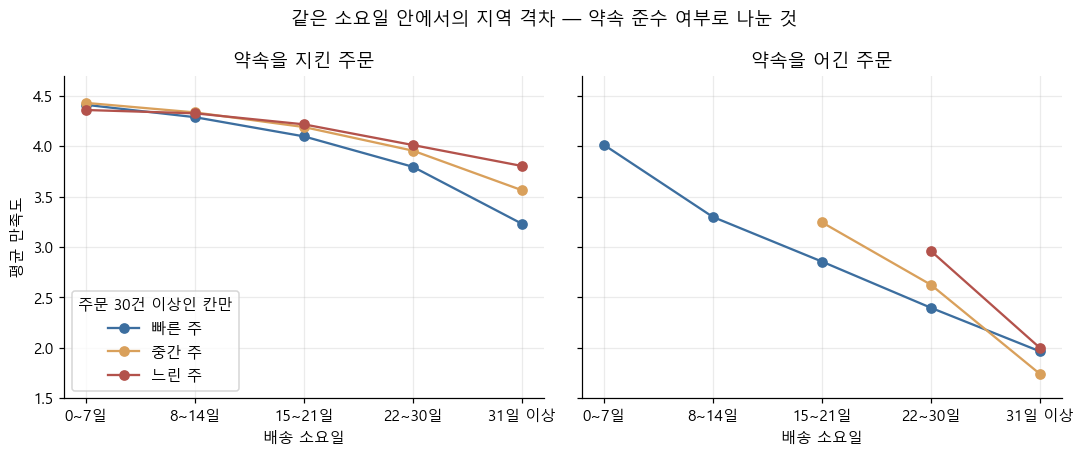

In [18]:
df = con.execute("""
WITH state_speed AS (
    SELECT customer_state,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '중간 주'
                ELSE                                  '느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
)
SELECT CASE WHEN d.delivery_days <=  7 THEN '0~7일'
            WHEN d.delivery_days <= 14 THEN '8~14일'
            WHEN d.delivery_days <= 21 THEN '15~21일'
            WHEN d.delivery_days <= 30 THEN '22~30일'
            ELSE                            '31일 이상' END AS days_bucket,
       s.speed_group,
       d.days_vs_promise <= 0                              AS kept,
       COUNT(*)                                            AS orders,
       AVG(d.review_score)                                 AS avg_score
FROM delivery_review AS d
JOIN state_speed     AS s ON d.customer_state = s.customer_state
GROUP BY days_bucket, s.speed_group, kept
""").df()

order = ['0~7일', '8~14일', '15~21일', '22~30일', '31일 이상']
groups = [('빠른 주', FAST), ('중간 주', MID), ('느린 주', SLOW)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True)
for ax, kept, title in zip(axes, [True, False], ['약속을 지킨 주문', '약속을 어긴 주문']):
    for name, color in groups:
        sub = df[(df.kept == kept) & (df.speed_group == name)].set_index('days_bucket')
        sub = sub.reindex(order)
        sub = sub[sub.orders >= 30]
        ax.plot(sub.index, sub.avg_score, marker='o', color=color, label=name)
    ax.set_title(title)
    ax.set_xlabel('배송 소요일')
axes[0].set_ylabel('평균 만족도')
axes[0].set_ylim(1.5, 4.7)
axes[0].legend(title='주문 30건 이상인 칸만')
fig.suptitle('같은 소요일 안에서의 지역 격차 — 약속 준수 여부로 나눈 것')
plt.tight_layout()
plt.show()

**약속을 지킨 주문만 놓고 봐도 지역 격차가 남는다.**
0 ~ 7 일 4.41 · 4.43 · 4.36, 8 ~ 14 일 4.29 · 4.34 · 4.33 으로 짧은 구간은 차이가 없고,
15 ~ 21 일 4.10 · 4.19 · 4.22, 22 ~ 30 일 3.80 · 3.96 · 4.01, 31 일 이상 3.23 · 3.56 · 3.80 으로
소요일이 길수록 격차가 커진다. 빠른 주와 느린 주의 차이가 0.12 → 0.21 → 0.57.

같은 22 ~ 30 일 구간에서 격차가 0.77 이었던 것이 약속을 맞추고 나면 0.21 로 줄어든다.
**0.77 중 약 0.56 은 약속 위반율 차이에서 왔고, 0.21 이 지역 기준선의 몫이다.**

약속을 어긴 주문에서도 방향이 같다. 22 ~ 30 일에서 2.40 · 2.63 · 2.96.
같은 정도로 약속을 어겨도 느린 주가 덜 낮게 평가한다.

지역별 기준선은 실재하며, 그 작용의 상당 부분이 약속을 통해 이루어진다.
약속을 통제한 뒤에도 잔여분이 남고, 소요일이 길어질수록 그 잔여분이 커지는 것도
기준선 차이가 예측하는 방향이다.

31 일 이상 구간은 표본이 113 · 309 · 372 로 작아 값이 흔들릴 수 있다.

## 7. 기준선을 지역에 맞춰 옮기면 격차가 사라지는가

6 에서 절대 소요일로 자르면 지역 간 격차가 남았음. 그 격차의 정체가 기준선 차이라면,
**기준선을 지역에 맞춰 옮긴 뒤에는 격차가 사라져야 함.**

기준선 후보 둘을 같은 방식으로 확인.

- **지역 기준 대비** — `배송 소요일 − 그 주의 중앙값`. 그 지역의 통상 속도가 기준
- **약속 대비** — `배송 소요일 − (예상 도착일 − 구매일)`. 주문 시점에 플랫폼이 제시한 날짜가 기준

절대 소요일이 만족도에 영향을 준다는 것은 이미 확인된 사실이고, 여기서 보는 것은
그 위에 지역별 기준선이 얹히는지 여부. 둘은 서로 대체 관계가 아님.

먼저 예상 도착일이 지역차를 반영하고 있는지 확인. 반영하지 않는다면 약속 대비는
지역 기준선의 후보가 되지 못함.

In [19]:
con.execute("""
SELECT customer_state,
       COUNT(*)                                                                   AS orders,
       MEDIAN(delivery_days)                                                      AS actual_median,
       MEDIAN(date_diff('day', order_purchase_timestamp,
                               order_estimated_delivery_date))                    AS promised_median,
       MEDIAN(date_diff('day', order_purchase_timestamp,
                               order_estimated_delivery_date))
     - MEDIAN(delivery_days)                                                      AS slack_median
FROM delivery_review
GROUP BY customer_state
ORDER BY actual_median DESC
""").df()

,customer_state,orders,actual_median,promised_median,slack_median
0,AM,144,26.0,46.0,20.0
1,RR,40,25.0,45.0,20.0
2,AP,66,24.5,48.0,23.5
3,AL,393,22.0,32.0,10.0
4,PA,929,21.0,37.0,16.0
5,MA,709,19.0,31.0,12.0
6,RO,242,18.0,38.0,20.0
7,PB,511,18.0,33.0,15.0
8,SE,331,18.0,30.0,12.0
9,CE,1267,18.0,32.0,14.0


예상 도착일은 지역차를 강하게 반영. 약속의 중앙값이 SP 19 일, AM 46 일로 실제 소요일의 차이를
그대로 따라감. 여유분(약속 − 실제)도 SP 12 일, 느린 주는 16 ~ 23.5 일로 더 크게 얹혀 있음.

플랫폼이 지역별 배송 사정을 이미 알고 약속에 반영하고 있다는 뜻.
따라서 약속은 지역 기준선의 후보가 됨.

In [20]:
con.execute("""
WITH state_stat AS (
    SELECT customer_state,
           MEDIAN(delivery_days) AS state_median,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '1. 빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '2. 중간 주'
                ELSE                                  '3. 느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
),
j AS (
    SELECT d.review_score,
           s.speed_group,
           d.delivery_days - s.state_median AS rel_days
    FROM delivery_review AS d
    JOIN state_stat      AS s ON d.customer_state = s.customer_state
)
SELECT CASE WHEN rel_days <  -7 THEN '1. 기준보다 8일 이상 빠름'
            WHEN rel_days <  -2 THEN '2. 3~7일 빠름'
            WHEN rel_days <=  2 THEN '3. 기준 ±2일'
            WHEN rel_days <=  7 THEN '4. 3~7일 늦음'
            WHEN rel_days <= 14 THEN '5. 8~14일 늦음'
            ELSE                     '6. 15일 이상 늦음' END           AS rel_bucket,
       COUNT(*) FILTER (speed_group = '1. 빠른 주')                    AS n_fast,
       ROUND(AVG(review_score) FILTER (speed_group = '1. 빠른 주'), 2) AS score_fast,
       COUNT(*) FILTER (speed_group = '2. 중간 주')                    AS n_mid,
       ROUND(AVG(review_score) FILTER (speed_group = '2. 중간 주'), 2) AS score_mid,
       COUNT(*) FILTER (speed_group = '3. 느린 주')                    AS n_slow,
       ROUND(AVG(review_score) FILTER (speed_group = '3. 느린 주'), 2) AS score_slow
FROM j
GROUP BY rel_bucket
ORDER BY rel_bucket
""").df()

,rel_bucket,n_fast,score_fast,n_mid,score_mid,n_slow,score_slow
0,1. 기준보다 8일 이상 빠름,165,4.45,1553,4.49,983,4.39
1,2. 3~7일 빠름,13404,4.44,9081,4.38,2017,4.29
2,3. 기준 ±2일,24188,4.34,9245,4.30,1836,4.22
3,4. 3~7일 늦음,11214,4.21,5184,4.16,1307,4.01
4,5. 8~14일 늦음,5020,3.92,3358,3.81,912,3.61
5,6. 15일 이상 늦음,2311,2.68,2899,2.24,883,2.31


지역 기준 대비로 자르면 격차가 사라지지 않고 **방향이 뒤집힘.**
기준 ±2 일에서 빠른 주 4.34 · 느린 주 4.22, 8 ~ 14 일 늦음에서 빠른 주 3.92 · 느린 주 3.61.
절대 소요일로 잘랐을 때는 느린 주가 높았으나(3.13 대 3.90) 여기서는 느린 주가 낮다.

과보정. 느린 주에서 "기준보다 10 일 늦음"은 절대 36 일이고, 그 절대 길이가 여전히 작동한다.
지역의 통상 속도는 기준선을 완전히 대리하지 못함.

In [21]:
con.execute("""
WITH state_stat AS (
    SELECT customer_state,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '1. 빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '2. 중간 주'
                ELSE                                  '3. 느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
)
SELECT CASE WHEN days_vs_promise <= -21 THEN '1. 21일 이상 빠름'
            WHEN days_vs_promise <= -11 THEN '2. 11~20일 빠름'
            WHEN days_vs_promise <=  -3 THEN '3. 3~10일 빠름'
            WHEN days_vs_promise <=  -1 THEN '4. 1~2일 빠름'
            WHEN days_vs_promise =    0 THEN '5. 약속 당일'
            WHEN days_vs_promise <=   2 THEN '6. 1~2일 늦음'
            WHEN days_vs_promise <=  10 THEN '7. 3~10일 늦음'
            ELSE                             '8. 11일 이상 늦음' END   AS promise_bucket,
       COUNT(*)                                                        AS orders,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2)              AS pct,
       ROUND(AVG(review_score), 2)                                     AS avg_all,
       ROUND(AVG(review_score) FILTER (speed_group = '1. 빠른 주'), 2) AS score_fast,
       ROUND(AVG(review_score) FILTER (speed_group = '2. 중간 주'), 2) AS score_mid,
       ROUND(AVG(review_score) FILTER (speed_group = '3. 느린 주'), 2) AS score_slow
FROM delivery_review AS d
JOIN state_stat      AS s ON d.customer_state = s.customer_state
GROUP BY promise_bucket
ORDER BY promise_bucket
""").df()

,promise_bucket,orders,pct,avg_all,score_fast,score_mid,score_slow
0,1. 21일 이상 빠름,13170,13.78,4.29,4.30,4.30,4.25
1,2. 11~20일 빠름,43482,45.50,4.33,4.35,4.32,4.24
2,3. 3~10일 빠름,28261,29.57,4.25,4.29,4.20,4.11
3,4. 1~2일 빠름,2989,3.13,4.14,4.22,4.07,3.82
4,5. 약속 당일,1280,1.34,4.03,4.03,4.06,3.93
5,6. 1~2일 늦음,1355,1.42,3.51,3.60,3.37,3.61
6,7. 3~10일 늦음,3000,3.14,2.09,2.20,1.98,2.06
7,8. 11일 이상 늦음,2023,2.12,1.71,1.88,1.60,1.78


약속 대비로 자르면 지역 간 격차가 가장 작아짐. 절대 기준에서 0.77 이던 격차가
0.1 ~ 0.3 수준으로 줄어듦.

약속을 지킨 구간은 만족도가 4.25 ~ 4.33 으로 평평. **약속보다 더 일찍 온다고 만족도가 오르지 않음.**

약속을 넘기는 순간 값이 꺾임. 당일 4.03 에서 1 ~ 2 일 늦음 3.51 로 0.52 하락.
약속을 어긴 주문은 6,378 건으로 표본의 6.7 %.

In [22]:
con.execute("""
SELECT CASE WHEN days_vs_promise <= 14 THEN CAST(days_vs_promise AS VARCHAR)
            WHEN days_vs_promise <= 30 THEN '15~30'
            ELSE                           '31+' END                    AS days_late,
       COUNT(*)                                                        AS orders,
       ROUND(AVG(review_score), 3)                                     AS avg_score,
       ROUND(100.0 * COUNT(*) FILTER (review_score = 1) / COUNT(*), 1)  AS pct_1,
       ROUND(100.0 * COUNT(*) FILTER (review_score >= 4) / COUNT(*), 1) AS pct_45,
       ROUND(MEDIAN(delivery_days), 1)                                 AS median_days
FROM delivery_review
WHERE days_vs_promise >= 0
GROUP BY days_late
ORDER BY CASE WHEN days_late = '15~30' THEN 15
              WHEN days_late = '31+'   THEN 31
              ELSE CAST(days_late AS INTEGER) END
""").df()

,days_late,orders,avg_score,pct_1,pct_45,median_days
0,0,1280,4.034,8.5,73.7,20.0
1,1,819,3.731,13.1,65.2,23.0
2,2,536,3.179,27.4,50.2,24.0
3,3,496,2.683,42.5,36.5,25.0
4,4,436,2.498,48.2,32.3,26.0
5,5,434,2.196,55.3,24.9,28.0
6,6,407,1.811,68.6,16.0,29.0
7,7,471,1.911,62.6,17.0,30.0
8,8,330,1.709,68.8,11.5,31.0
9,9,219,1.667,72.1,11.4,33.0


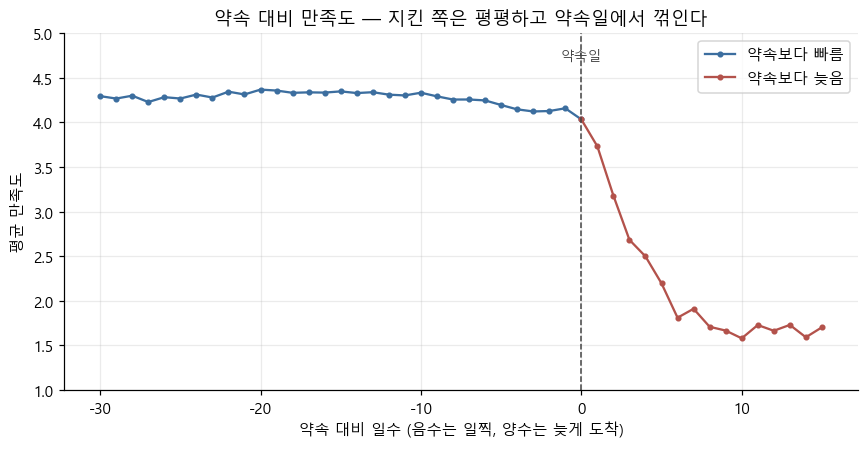

In [23]:
df = con.execute("""
SELECT days_vs_promise   AS d,
       COUNT(*)          AS orders,
       AVG(review_score) AS avg_score
FROM delivery_review
WHERE days_vs_promise BETWEEN -30 AND 15
GROUP BY d
HAVING COUNT(*) >= 100
ORDER BY d
""").df()

fig, ax = plt.subplots(figsize=(8, 4.2))
early = df[df.d <= 0]
late = df[df.d >= 0]
ax.plot(early.d, early.avg_score, marker='o', ms=3, color='#3C6E9F', label='약속보다 빠름')
ax.plot(late.d, late.avg_score, marker='o', ms=3, color='#B3524B', label='약속보다 늦음')
ax.axvline(0, color='#444', lw=1, ls='--')
ax.annotate('약속일', xy=(0, 4.7), fontsize=9, color='#444', ha='center')
ax.set_xlabel('약속 대비 일수 (음수는 일찍, 양수는 늦게 도착)')
ax.set_ylabel('평균 만족도')
ax.set_ylim(1, 5)
ax.set_title('약속 대비 만족도 — 지킨 쪽은 평평하고 약속일에서 꺾인다')
ax.legend()
plt.tight_layout()
plt.show()

지연을 하루 단위로 펼치면 **첫 일주일에 하락이 몰려 있음.**
0 일 4.034, 1 일 3.731, 2 일 3.179, 3 일 2.683, 4 일 2.498, 5 일 2.196, 6 일 1.811 로
하루당 약 0.37 씩 떨어짐. 1 점 비율은 8.5 % 에서 68.6 % 로 커짐.

6 일을 지나면 1.6 ~ 1.9 에서 더 내려가지 않음. 8 일 1.709, 10 일 1.580, 14 일 1.592,
15 ~ 30 일 1.614. 이미 최악에 도달해 더 늦어져도 값이 움직이지 않음.

31 일 이상 늦은 328 건만 2.061 로 올라섬. 이 데이터로 원인을 확인할 근거는 없음.

이 하락에는 지연 자체의 효과와 오래 기다린 것의 효과가 섞여 있음.
실제 소요일 중앙값이 0 일 지연에서 20 일, 8 일 지연에서 31 일, 15 ~ 30 일 지연에서 45 일로
함께 길어짐. 둘을 가르는 작업은 아래 교차표에서 수행.

In [24]:
con.execute("""
SELECT CASE WHEN delivery_days <=  7 THEN '1. 0~7일'
            WHEN delivery_days <= 14 THEN '2. 8~14일'
            WHEN delivery_days <= 21 THEN '3. 15~21일'
            WHEN delivery_days <= 30 THEN '4. 22~30일'
            ELSE                          '5. 31일 이상' END              AS days_bucket,
       COUNT(*) FILTER (days_vs_promise <  0)                             AS n_early,
       ROUND(AVG(review_score) FILTER (days_vs_promise <  0), 2)          AS score_early,
       COUNT(*) FILTER (days_vs_promise = 0)                              AS n_ontime,
       ROUND(AVG(review_score) FILTER (days_vs_promise = 0), 2)           AS score_ontime,
       COUNT(*) FILTER (days_vs_promise BETWEEN 1 AND 4)                  AS n_late1,
       ROUND(AVG(review_score) FILTER (days_vs_promise BETWEEN 1 AND 4), 2) AS score_late1,
       COUNT(*) FILTER (days_vs_promise >= 5)                             AS n_late5,
       ROUND(AVG(review_score) FILTER (days_vs_promise >= 5), 2)          AS score_late5
FROM delivery_review
GROUP BY days_bucket
ORDER BY days_bucket
""").df()

,days_bucket,n_early,score_early,n_ontime,score_ontime,n_late1,score_late1,n_late5,score_late5
0,1. 0~7일,30261,4.41,181,4.39,74,3.97,0,NaN
1,2. 8~14일,37156,4.31,205,4.12,262,3.63,72,1.97
2,3. 15~21일,15078,4.16,336,4.06,420,3.27,161,2.07
3,4. 22~30일,4726,3.94,445,3.92,1131,3.06,917,1.92
4,5. 31일 이상,681,3.62,113,3.65,400,2.76,2941,1.72


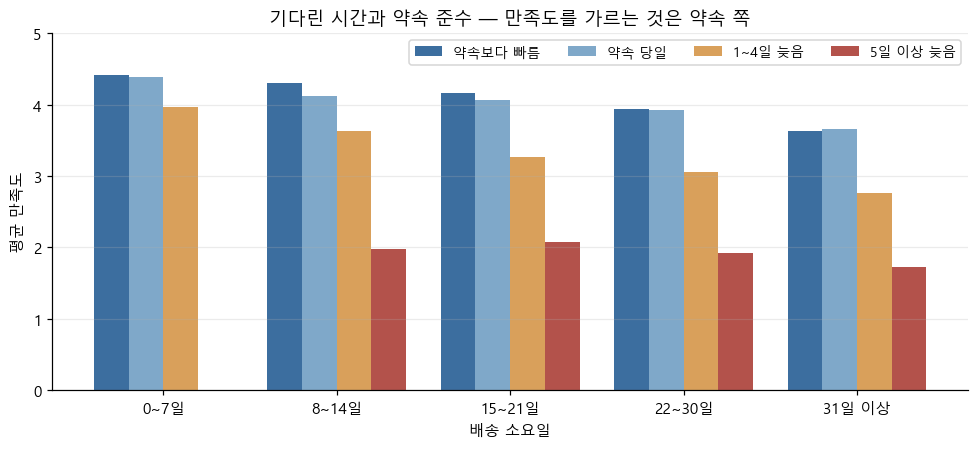

In [25]:
df = con.execute("""
SELECT CASE WHEN delivery_days <=  7 THEN '0~7일'
            WHEN delivery_days <= 14 THEN '8~14일'
            WHEN delivery_days <= 21 THEN '15~21일'
            WHEN delivery_days <= 30 THEN '22~30일'
            ELSE                          '31일 이상' END AS days_bucket,
       CASE WHEN days_vs_promise <  0 THEN '1. 약속보다 빠름'
            WHEN days_vs_promise =  0 THEN '2. 약속 당일'
            WHEN days_vs_promise <= 4 THEN '3. 1~4일 늦음'
            ELSE                          '4. 5일 이상 늦음' END AS promise_status,
       COUNT(*)                                          AS orders,
       AVG(review_score)                                 AS avg_score
FROM delivery_review
GROUP BY days_bucket, promise_status
""").df()

order = ['0~7일', '8~14일', '15~21일', '22~30일', '31일 이상']
status = ['1. 약속보다 빠름', '2. 약속 당일', '3. 1~4일 늦음', '4. 5일 이상 늦음']
colors = ['#3C6E9F', '#7FA8C9', '#D9A05B', '#B3524B']

fig, ax = plt.subplots(figsize=(9, 4.2))
w = 0.2
for k, (st, color) in enumerate(zip(status, colors)):
    sub = df[df.promise_status == st].set_index('days_bucket').reindex(order)
    sub.loc[sub.orders < 30, 'avg_score'] = None
    xs = [i + (k - 1.5) * w for i in range(len(order))]
    ax.bar(xs, sub.avg_score, width=w, color=color, label=st[3:])
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('배송 소요일')
ax.set_ylabel('평균 만족도')
ax.set_ylim(0, 5)
ax.set_title('기다린 시간과 약속 준수 — 만족도를 가르는 것은 약속 쪽')
ax.legend(ncols=4, fontsize=9)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

두 축을 교차하면 어느 쪽이 만족도를 더 크게 움직이는지 갈림.

**약속을 지킨 주문만 보면**(약속보다 빠름 열) 절대 소요일이 0 ~ 7 일에서 31 일 이상으로 늘어도
4.41 → 3.62 로 0.79 하락.

**같은 절대 구간 안에서 약속을 어기면** 1 ~ 4 일 늦을 때 0.44 ~ 0.89, 5 일 이상 늦을 때
1.9 ~ 2.3 하락. 절대 소요일 전체 범위가 만드는 차이보다 큼.

가장 선명한 대비는 31 일 넘게 걸렸어도 약속을 지킨 주문이 3.62 인 반면,
8 ~ 14 일 만에 도착했어도 5 일 늦은 주문이 1.97 이라는 것.
실제 대기 시간은 서너 배 차이인데 만족도는 반대 방향.

**고객 만족은 얼마나 기다렸는가보다 약속이 지켜졌는가에 두 배 이상 민감.**

## 8. 약속을 지킨 쪽에서도 여유가 만족도를 움직이는가

7 에서 약속을 어기면 지연 일수에 비례해 만족도가 떨어지는 것을 확인. 남은 것은 반대쪽 —
**약속을 지킨 주문들 사이에서 여유가 클수록 만족도가 높은가.**

이 답에 따라 패딩의 성격이 갈림.

- 여유가 클수록 만족도가 오른다면 → 약속을 늘리는 만큼 계속 이득
- 여유의 길이와 무관하다면 → 위반을 없애고 그 정도를 줄이는 만큼만 이득

구분하려면 실제 배송 경험이 비슷한 주문들 사이에서 약속만 다른 경우를 비교해야 함.
각 주의 중앙값 ±2 일에 든 주문으로 좁히고, 여유는 `약속 − 실제`로 정의.

**이 비교가 답하지 못하는 것.** 지역과 실제 소요일을 맞춰도 약속이 왜 다르게 붙었는지는 통제하지 못함.
예상 도착일은 무작위로 정해지는 값이 아니라 판매자 위치나 상품 같은 요인을 반영해 산출되므로,
약속이 긴 주문은 애초에 다른 성격의 주문일 수 있음. 그 요인들을 조건에 더 넣으면 표본이 쪼개지고
관측되지 않는 요인은 여전히 남는다.

따라서 이 절의 결과는 약속을 늘리는 개입의 효과가 아니라
**관측 자료에서 그 관계가 드러나는지 여부**로만 읽어야 함.

In [26]:
con.execute("""
WITH med AS (
    SELECT customer_state,
           MEDIAN(delivery_days) AS state_median,
           CASE WHEN MEDIAN(delivery_days) <= 10 THEN '1. 빠른 주'
                WHEN MEDIAN(delivery_days) <= 16 THEN '2. 중간 주'
                ELSE                                  '3. 느린 주' END AS speed_group
    FROM delivery_review
    GROUP BY customer_state
),
b AS (
    SELECT d.review_score,
           m.speed_group,
           -d.days_vs_promise AS slack
    FROM delivery_review AS d
    JOIN med              AS m ON d.customer_state = m.customer_state
    WHERE abs(d.delivery_days - m.state_median) <= 2
)
SELECT CASE WHEN slack <   0 THEN '0. 약속 위반'
            WHEN slack <=  4 THEN '1. 여유 0~4일'
            WHEN slack <=  9 THEN '2. 여유 5~9일'
            WHEN slack <= 14 THEN '3. 여유 10~14일'
            WHEN slack <= 19 THEN '4. 여유 15~19일'
            ELSE                  '5. 여유 20일 이상' END               AS slack_bucket,
       COUNT(*) FILTER (speed_group = '1. 빠른 주')                     AS n_fast,
       ROUND(AVG(review_score) FILTER (speed_group = '1. 빠른 주'), 3)  AS score_fast,
       COUNT(*) FILTER (speed_group = '2. 중간 주')                     AS n_mid,
       ROUND(AVG(review_score) FILTER (speed_group = '2. 중간 주'), 3)  AS score_mid,
       COUNT(*) FILTER (speed_group = '3. 느린 주')                     AS n_slow,
       ROUND(AVG(review_score) FILTER (speed_group = '3. 느린 주'), 3)  AS score_slow
FROM b
GROUP BY slack_bucket
ORDER BY slack_bucket
""").df()

,slack_bucket,n_fast,score_fast,n_mid,score_mid,n_slow,score_slow
0,0. 약속 위반,132,3.659,23,2.870,8,3.500
1,1. 여유 0~4일,1279,4.337,252,4.270,61,3.984
2,2. 여유 5~9일,5123,4.315,1440,4.313,330,4.200
3,3. 여유 10~14일,8130,4.350,3217,4.309,544,4.200
4,4. 여유 15~19일,5755,4.383,2269,4.305,515,4.229
5,5. 여유 20일 이상,3769,4.339,2044,4.281,378,4.283


여유 0 ~ 4 일부터 20 일 이상까지 만족도가 빠른 주 4.32 ~ 4.38, 중간 주 4.27 ~ 4.31,
느린 주 3.98 ~ 4.28 로 거의 평평. 위반만 3.66 · 2.87 · 3.50 으로 떨어져 있음.

다만 주는 지리적 폭이 커서 같은 주 안에 근거리와 원거리가 섞임.
약속이 짧게 잡힌 주문이 근거리에 몰려 있다면 여기서 본 평평함이 통제 부족의 결과일 수 있음.
느린 주는 칸마다 표본이 61 ~ 544 건이라 흔들림도 큼.

도시 단위로 좁혀 재확인. 도시 하나로 한정하면 표본과 일반성을 잃으므로,
각 주문을 자기 도시와 비교하는 방식으로 134 개 도시를 함께 사용.

In [27]:
con.execute("""
WITH city AS (
    SELECT customer_state,
           customer_city,
           COUNT(*)              AS city_orders,
           SUM(review_score)     AS city_score_sum,
           MEDIAN(delivery_days) AS city_median
    FROM delivery_review
    GROUP BY customer_state, customer_city
    HAVING COUNT(*) >= 100
),
b AS (
    SELECT d.review_score,
           d.review_score
             - (c.city_score_sum - d.review_score) / (c.city_orders - 1) AS score_dev,
           -d.days_vs_promise                                            AS slack
    FROM delivery_review AS d
    JOIN city            AS c ON d.customer_state = c.customer_state
                             AND d.customer_city  = c.customer_city
    WHERE abs(d.delivery_days - c.city_median) <= 2
)
SELECT CASE WHEN slack <   0 THEN '0. 약속 위반'
            WHEN slack <=  4 THEN '1. 여유 0~4일'
            WHEN slack <=  9 THEN '2. 여유 5~9일'
            WHEN slack <= 14 THEN '3. 여유 10~14일'
            WHEN slack <= 19 THEN '4. 여유 15~19일'
            WHEN slack <= 24 THEN '5. 여유 20~24일'
            ELSE                  '6. 여유 25일 이상' END AS slack_bucket,
       COUNT(*)                                         AS orders,
       ROUND(AVG(review_score), 3)                      AS avg_score,
       ROUND(AVG(score_dev), 3)                         AS dev_from_city,
       ROUND(STDDEV_SAMP(score_dev) / SQRT(COUNT(*)), 3) AS se_dev
FROM b
GROUP BY slack_bucket
ORDER BY slack_bucket
""").df()

,slack_bucket,orders,avg_score,dev_from_city,se_dev
0,0. 약속 위반,153,3.536,-0.640,0.125
1,1. 여유 0~4일,1472,4.328,0.142,0.029
2,2. 여유 5~9일,5753,4.310,0.133,0.015
3,3. 여유 10~14일,8091,4.333,0.164,0.012
4,4. 여유 15~19일,5356,4.334,0.158,0.015
5,5. 여유 20~24일,2366,4.338,0.171,0.024
6,6. 여유 25일 이상,1447,4.263,0.127,0.032


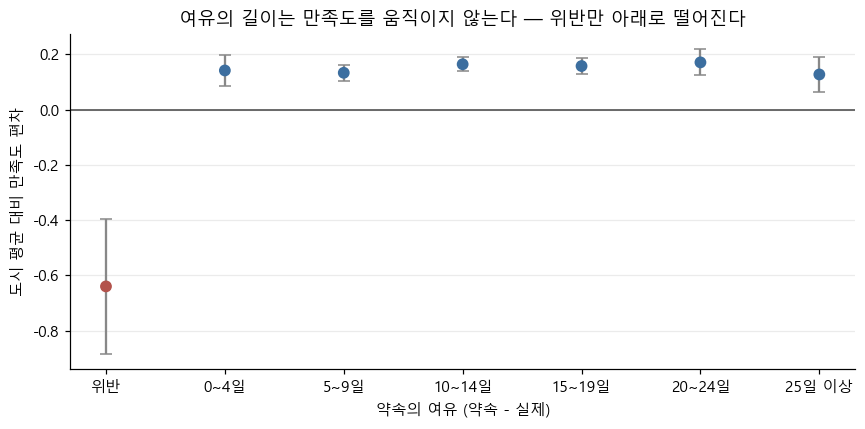

In [28]:
df = con.execute("""
WITH city AS (
    SELECT customer_state, customer_city,
           COUNT(*)              AS city_orders,
           SUM(review_score)     AS city_score_sum,
           MEDIAN(delivery_days) AS city_median
    FROM delivery_review
    GROUP BY customer_state, customer_city
    HAVING COUNT(*) >= 100
),
b AS (
    SELECT d.review_score
             - (c.city_score_sum - d.review_score) / (c.city_orders - 1) AS score_dev,
           -d.days_vs_promise                                            AS slack
    FROM delivery_review AS d
    JOIN city            AS c ON d.customer_state = c.customer_state
                             AND d.customer_city  = c.customer_city
    WHERE abs(d.delivery_days - c.city_median) <= 2
)
SELECT CASE WHEN slack <   0 THEN '위반'
            WHEN slack <=  4 THEN '0~4일'
            WHEN slack <=  9 THEN '5~9일'
            WHEN slack <= 14 THEN '10~14일'
            WHEN slack <= 19 THEN '15~19일'
            WHEN slack <= 24 THEN '20~24일'
            ELSE                  '25일 이상' END AS slack_bucket,
       COUNT(*)                                  AS orders,
       AVG(score_dev)                            AS dev,
       STDDEV_SAMP(score_dev) / SQRT(COUNT(*))   AS se
FROM b
GROUP BY slack_bucket
""").df()

order = ['위반', '0~4일', '5~9일', '10~14일', '15~19일', '20~24일', '25일 이상']
df = df.set_index('slack_bucket').reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [SLOW] + [FAST] * 6
ax.errorbar(range(len(order)), df.dev, yerr=1.96 * df.se, fmt='none', ecolor='#888', capsize=4)
ax.scatter(range(len(order)), df.dev, color=colors, zorder=3, s=45)
ax.axhline(0, color='#444', lw=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order)
ax.set_xlabel('약속의 여유 (약속 - 실제)')
ax.set_ylabel('도시 평균 대비 만족도 편차')
ax.set_title('여유의 길이는 만족도를 움직이지 않는다 — 위반만 아래로 떨어진다')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

주문 100 건 이상인 도시 134 개(표본의 66 %)가 대상.
각 주문의 만족도를 그 도시의 평균과 비교하고, 그 도시의 중앙값 ±2 일에 든 건만 남겼다.
비교 기준이 되는 도시 평균에서는 그 주문 자신을 뺐다.
도시별 만족도 기준선과 배송 속도 차이가 함께 제거된다.

여유 구간은 도시 평균 대비 +0.127 ~ +0.171 사이에 모두 들어온다. 여유를 4 일 주든 24 일 주든 값이 같다.
위반만 −0.640.

**관측된 범위에서 여유의 길이는 만족도와 관계를 보이지 않는다.**

7 의 결과와 합치면 약속 대비 만족도는 0 에서 꺾이는 비대칭 곡선이다.
지킨 쪽은 여유가 얼마든 평평하고, 어긴 쪽은 지연 일수에 비례해 6 일까지 급락한 뒤 바닥에 붙는다.

개입의 효과로 읽을 수는 없다. 같은 도시에서 약속이 갈리는 이유가 통제되지 않았으므로,
여유가 큰 주문이 다른 성격의 주문이어서 효과가 상쇄되었을 가능성이 남아 있다.

## 9. 패딩을 적용하면 얼마나 달라지는가

약속 대비 만족도는 0 에서 꺾이는 비대칭 곡선. 지킨 쪽은 여유의 길이와 무관하게 평평하고,
어긴 쪽은 지연 일수에 비례해 떨어짐.

따라서 패딩이 만드는 이득은 둘. **위반을 지킴으로 바꾸는 것**과,
**여전히 늦는 주문의 지연 일수를 줄이는 것.** 여유를 더 얹어 기대를 낮추는 방식의 이득은 없음.

주문마다 지연 일수에서 패딩 일수를 빼고, 절대 소요일을 고정한 채 그 지연 수준의 관측 평균으로
바꿔 전체를 다시 계산. 7 의 교차표 칸을 그대로 사용.

가정 둘을 깔고 있으며 둘 다 이 데이터로 확인할 수 없음.

- 관측된 지연-만족도 관계가 약속을 바꾼 뒤에도 유지됨. 8 에서 본 것은 자연히 생긴 약속 차이이지
  의도적으로 옮긴 결과가 아님
- 약속을 늘려도 주문 자체는 줄지 않음. 완료된 주문만 기록되어 있어 주문하지 않은 사람이
  관측되지 않음
- 패딩으로 칸을 옮긴 주문에 그 칸의 관측 평균을 그대로 붙임. 옮겨간 주문은 원래 그 칸에 있던
  주문보다 아슬아슬하게 들어온 쪽이라 실제 값이 관측 평균보다 낮을 가능성이 크다.
  이 치우침은 방향이 정해져 있어 아래 수치는 **과대추정 쪽, 즉 상한에 가깝다**

따라서 아래 수치는 개입의 예측이 아니라 **관측된 관계가 유지된다는 조건에서의 값**.

In [29]:
pad = con.execute("""
WITH base AS (
    SELECT CASE WHEN delivery_days <=  7 THEN '1. 0~7일'
                WHEN delivery_days <= 14 THEN '2. 8~14일'
                WHEN delivery_days <= 21 THEN '3. 15~21일'
                WHEN delivery_days <= 30 THEN '4. 22~30일'
                ELSE                          '5. 31일 이상' END AS days_bucket,
           days_vs_promise,
           review_score
    FROM delivery_review
),
cell_stat AS (
    SELECT days_bucket,
           CASE WHEN days_vs_promise <  0 THEN 'early'
                WHEN days_vs_promise =  0 THEN 'ontime'
                WHEN days_vs_promise <= 4 THEN 'late1'
                ELSE                          'late5' END AS promise_status,
           AVG(review_score)                                        AS mean_score,
           AVG(CASE WHEN review_score = 1 THEN 1.0 ELSE 0.0 END)    AS rate_1
    FROM base
    GROUP BY days_bucket, promise_status
),
pads AS (SELECT UNNEST([0, 3, 5, 7, 10, 14]) AS pad),
shifted AS (
    SELECT p.pad,
           b.days_bucket,
           CASE WHEN b.days_vs_promise - p.pad <  0 THEN 'early'
                WHEN b.days_vs_promise - p.pad =  0 THEN 'ontime'
                WHEN b.days_vs_promise - p.pad <= 4 THEN 'late1'
                ELSE                                    'late5' END AS new_status,
           b.days_vs_promise - p.pad                                AS new_late
    FROM base AS b
    CROSS JOIN pads AS p
)
SELECT s.pad,
       ROUND(100.0 * COUNT(*) FILTER (s.new_late > 0) / COUNT(*), 2) AS late_pct,
       ROUND(AVG(c.mean_score), 3)                                   AS expected_score,
       ROUND(100.0 * AVG(c.rate_1), 2)                               AS expected_pct_1,
       ROUND(AVG(c.rate_1) * COUNT(*))                               AS expected_1_orders
FROM shifted   AS s
JOIN cell_stat AS c ON s.days_bucket = c.days_bucket
                   AND s.new_status  = c.promise_status
GROUP BY s.pad
ORDER BY s.pad
""").df()

pad


,pad,late_pct,expected_score,expected_pct_1,expected_1_orders
0,0,6.67,4.156,9.75,9314.0
1,3,4.74,4.189,8.94,8541.0
2,5,3.83,4.203,8.57,8192.0
3,7,2.91,4.215,8.25,7886.0
4,10,2.12,4.228,7.92,7571.0
5,14,1.39,4.238,7.63,7295.0


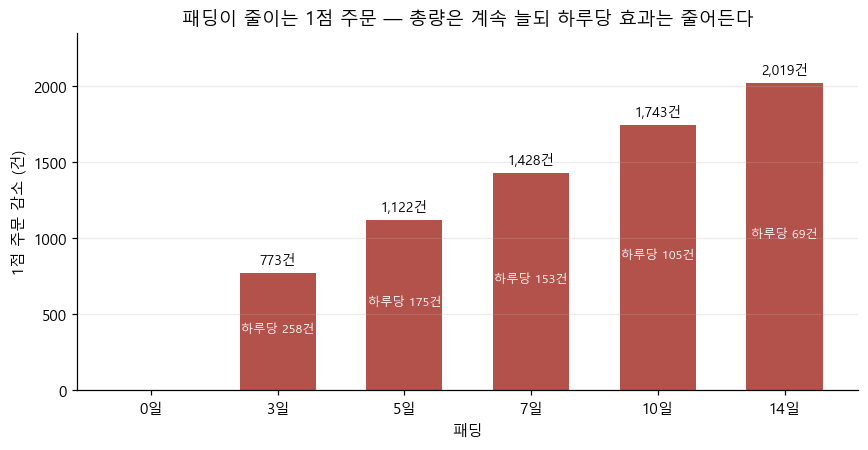

In [30]:
base = pad.expected_1_orders.iloc[0]
cut = base - pad.expected_1_orders
per_day = cut.diff() / pad.pad.diff()

fig, ax = plt.subplots(figsize=(8, 4.2))
xs = range(len(pad))
ax.bar(xs, cut, color='#B3524B', width=0.6)
for i, y in zip(xs, cut):
    if i == 0:
        continue
    ax.annotate(f'{y:,.0f}건', (i, y), textcoords='offset points', xytext=(0, 6),
                ha='center', fontsize=9)
    ax.annotate(f'하루당 {int(per_day.iloc[i] + 0.5):,}건', (i, y / 2), ha='center',
                fontsize=8, color='white')
ax.set_xticks(list(xs))
ax.set_xticklabels([f'{d}일' for d in pad.pad])
ax.set_xlabel('패딩')
ax.set_ylabel('1점 주문 감소 (건)')
ax.set_ylim(0, 2350)
ax.set_title('패딩이 줄이는 1점 주문 — 총량은 계속 늘되 하루당 효과는 줄어든다')
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.show()

패딩을 늘릴수록 위반율이 6.67 % 에서 1.39 % 까지 내려가고 기대 만족도는 4.156 에서 4.238 로 상승.

평균의 변화는 작다. 3 일 패딩에 +0.033, 5 일에 +0.047, 14 일에도 +0.082.
위반이 6.7 % 뿐이라 나머지 93.3 % 의 값이 평균을 붙들고 있다.

1 점 주문의 수로 보면 크기가 다르다. 3 일 패딩에 9,314 건에서 8,541 건으로 773 건 감소,
5 일 1,122 건, 7 일 1,428 건, 10 일 1,743 건, 14 일 2,019 건 감소.

이득은 위반이 사라진 주문뿐 아니라 **여전히 늦지만 덜 늦어진 주문**에서도 나온다.
지연 6 일이 3 일이 되면 1.81 에서 2.68 로 올라간다.

**패딩이 클수록 이득은 계속 커지되 증가 폭은 줄어든다.** 하루당 1 점 감소가
처음 3 일 구간에서 258 건, 3 ~ 5 일 175 건, 5 ~ 7 일 153 건, 7 ~ 10 일 105 건, 10 ~ 14 일 69 건.

패딩이 이득을 내는 방식은 늦은 도착을 없애는 것이 아니라 늦었다는 판정을 없애는 것이다.
실제 도착일은 그대로다. 날짜를 조금 미루는 동안은 고객이 그 차이를 감수할 만하지만,
계속 미루면 그 날짜를 보고 주문을 그만두는 쪽으로 넘어간다.
시뮬레이션은 이미 들어온 주문만 세므로 그 지점이 어디인지 계산에 나오지 않는다.

관측 범위도 같은 방향으로 제한을 건다. SP 의 약속 중앙값이 19 일인데 14 일을 얹으면 33 일이 되고,
그 지역에서 그만큼 긴 약속을 받은 주문은 거의 없어 위의 관계를 그대로 적용할 근거가 없다.
며칠 수준의 패딩은 관측 범위 안이라 같은 문제가 없다

## 10. 정리

### 가설의 판정

**가정 1 — 지역마다 배송 소요 시간이 다르고 만족의 기준선도 다르다.** 성립한다.
그 작용의 상당 부분은 예상 도착일을 통해 이루어진다.

주별 중앙값이 SP 7 일에서 AM 26 일까지 3.7 배 차이. 절대 소요일을 고정하고 지역을 비교하면
22 ~ 30 일 구간에서 빠른 주 3.13, 느린 주 3.90 으로 0.77 격차.

이 격차의 대부분은 지역별 기준선이 아니라 약속 위반율 차이에서 온다. 같은 25 일이라도
빠른 주는 약속이 19 일이라 어긴 것이고 느린 주는 46 일이라 지킨 것이다.
약속 준수 여부를 맞추고 비교하면 격차가 0.21 로 줄어든다.

**줄어들되 사라지지는 않는다.** 약속을 똑같이 지킨 주문끼리 비교해도 15 ~ 21 일 0.12,
22 ~ 30 일 0.21, 31 일 이상 0.57 로 남으며 소요일이 길수록 커진다.
약속을 어긴 주문 안에서도 방향이 같다.

**가정 2 — 그 기준선을 대리하는 것은 주문 시점에 제시된 예상 도착일이다.** 분석 과정에서 새로 생긴 것.

기준선 후보 둘을 각각 적용한 결과가 갈림. 지역의 통상 소요 시간으로 정규화하면 격차가 사라지지 않고
방향이 뒤집힘. 예상 도착일로 정규화하면 격차가 0.77 에서 0.1 ~ 0.3 으로 줄어듦.
예상 도착일은 이미 지역차를 반영해 산출되고 있음 — 약속 중앙값이 SP 19 일, AM 46 일.

두 축을 교차하면 크기가 드러남. 약속을 지킨 주문에서 절대 소요일이 0 ~ 7 일에서 31 일 이상으로
늘어날 때 만족도 하락은 0.79. 같은 절대 구간에서 약속을 5 일 이상 어길 때의 하락은 1.9 ~ 2.3.
31 일 넘게 걸렸어도 약속을 지키면 3.62, 8 ~ 14 일에 도착해도 5 일 늦으면 1.97.

약속 대비 만족도는 0 에서 꺾이는 비대칭 곡선. 지킨 쪽은 여유가 4 일이든 24 일이든 평평하고
(도시 평균 대비 +0.127 ~ +0.171), 어긴 쪽은 지연 1 일마다 약 0.37 씩 떨어져 6 일에 바닥.
곡선이 각 주문의 약속일에서 꺾인다는 것은 고객이 그 날짜를 기준으로 삼고 있다는 뜻.
다만 여유 쪽이 평평한 것은 여유가 큰 주문이 다른 성격의 주문이어서 상쇄된 결과일 수 있고,
약속을 의도적으로 옮겼을 때도 같은 관계가 유지되는지는 별개의 문제.

### 제안

지렛대는 약속 위반 6,378 건(6.7 %). 나머지 93.3 % 는 이미 만족도 4.2 ~ 4.35 로 안정적이며
약속보다 더 일찍 도착시켜도 값이 오르지 않음.

패딩이 클수록 1 점 주문은 계속 줄어들되 증가 폭은 감소.
3 일에 773 건, 14 일에 2,019 건.

**패딩이 없애는 것은 늦은 도착이 아니라 늦었다는 판정이다.** 실제 도착일은 그대로이고,
날짜를 계속 미루면 고객은 그 날짜를 보고 주문을 그만두는 쪽으로 넘어간다.
시뮬레이션은 이미 들어온 주문만 세므로 그 지점이 어디인지 나오지 않는다.
SP 의 약속 중앙값 19 일에 14 일을 얹은 33 일은 관측된 적이 거의 없는 길이이기도 하다.
소량 패딩은 시도할 근거가 있음 — 3 일이면 위반율 6.67 % 에서 4.74 %, 1 점 주문 773 건 감소.
5 일이면 3.83 % 와 1,122 건. 하루당 1 점 감소는 3 일까지 258 건, 5 일까지 175 건,
7 일까지 153 건으로 비슷하다가 그 뒤 105 건, 69 건으로 꺾인다.
며칠이 적정인지는 이 수치가 정하지 못하므로 작은 쪽부터 시험해야 한다.

**다만 이것을 확정하려면 실험이 필요.** 관측 데이터로는 약속을 의도적으로 옮겼을 때 고객의 기대가
따라 옮겨지는지 알 수 없음. 소량 패딩을 일부 구간에 적용하고 결과를 비교하는 방식으로 확인해야 함.

지연 5 일 초과 4,091 건은 실제 소요일 중앙값이 29 ~ 69 일이라 패딩으로 해결되지 않음.
약속 산정이 아니라 배송 자체가 실패한 건이며 운영 문제로 분리해 다뤄야 함.

패딩이 판매자의 발송을 늦출 우려는 설계로 해소 가능. 고객에게 제시하는 예상 도착일과
판매자에게 요구하는 발송 기한은 별개의 값이며 데이터에도 각각 기록되어 있음.

### 이 분석이 답하지 못하는 것

**예상 도착일을 늘리면 주문이 줄어드는가.** 확인 불가.
완료된 주문만 있고 조회나 이탈 기록이 없어 주문하지 않은 사람이 관측되지 않음.
패딩의 이득은 수치로 냈으나 비용은 잴 수 없음.

**약속을 옮기면 기대도 따라 옮겨지는가.** 확인 불가.
8 에서 본 것은 자연히 생긴 약속 차이이지 의도적으로 옮긴 결과가 아님.

**판단** — 데이터가 아니라 의견으로 남김. 전환이 줄더라도 매우 나쁜 경험을 만들지 않는 편이 낫다고 봄.
위반 주문의 1 점 비율이 62 ~ 71 % 라 단순히 점수가 낮은 것이 아니라 나쁜 경험으로 남으며,
전환 손실은 거래 한 건이지만 나쁜 경험은 그 고객의 이후 행동과 다른 고객의 구매 판단까지 영향.
다만 그 크기 역시 이 데이터로 잴 수 없음. 05 에서 확인한 대로 반복 주문이 관측되는 사람이 3 % 뿐이라
나쁜 경험이 이후 구매에 미치는 영향을 추적할 표본이 없음.


## 11. 연결 종료

DuckDB 파일은 한 프로세스만 쓰기 모드로 열 수 있으므로 다음 노트북을 위해 여기서 종료.

In [31]:
con.close()